Primer Parcial

Estudiante: Chelsea Melany Espinoza Cava

Carrera: Ing. de Sistemas

ase de datos original de cáncer de mama de Wisconsin

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [9]:
# 1. CARGA DE DATOS
# Definimos los nombres de las columnas según la documentación de la UCI
columnas = ['ID', 'Clump_Thickness', 'Cell_Size_Uniformity', 'Cell_Shape_Uniformity', 
            'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 
            'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']

# Cargamos el archivo .data
df_cancer = pd.read_csv('breast-cancer-wisconsin.data', names=columnas, sep=',', skipinitialspace=True)

In [10]:
# 2. LIMPIEZA DE DATOS FALTANTES ("?" -> NaN)
# En este dataset, los nulos suelen estar en la columna 'Bare_Nuclei'
df_cancer.replace('?', np.nan, inplace=True)

# Borramos el ID porque no sirve para predecir salud
df_cancer.drop('ID', axis=1, inplace=True)

print(f"--- Dataset 8: Cáncer de Mama (Wisconsin) ---")
print(f"Nulos detectados (como '?'): {df_cancer.isnull().sum().sum()}")

--- Dataset 8: Cáncer de Mama (Wisconsin) ---
Nulos detectados (como '?'): 16


In [11]:
# 3. NORMALIZACIÓN Y KNN (Imputación)
# Primero escalamos para que el KNN funcione correctamente
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_cancer), columns=df_cancer.columns)

# Llenamos los huecos con KNN (5 vecinos)
knn = KNNImputer(n_neighbors=5)
df_final_cancer = pd.DataFrame(knn.fit_transform(df_scaled), columns=df_cancer.columns)

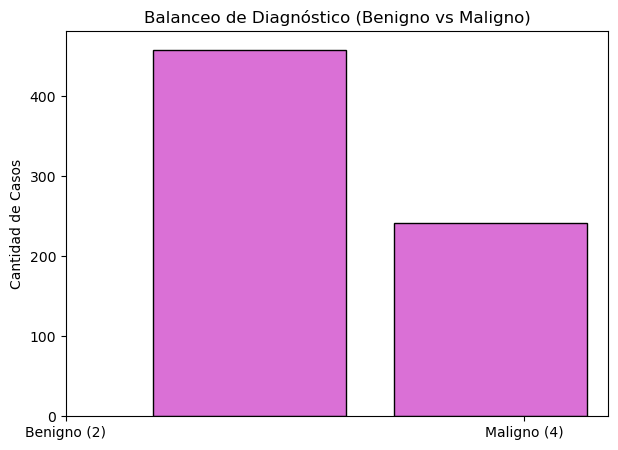

In [12]:
plt.figure(figsize=(7, 5))
plt.hist(df_final_cancer['Class'], bins=2, color='orchid', edgecolor='black', rwidth=0.8)
plt.title('Balanceo de Diagnóstico (Benigno vs Maligno)')
plt.xticks([-1, 1], ['Benigno (2)', 'Maligno (4)']) # Tras Z-score
plt.ylabel('Cantidad de Casos')
plt.show()

In [13]:
X = df_final_cancer.drop('Class', axis=1).values
y = df_final_cancer['Class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]}")
print(f"Prueba: {X_test.shape[0]}")

Entrenamiento: 559
Prueba: 140
